In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.interpolate import RectBivariateSpline, bisplrep, bisplev, griddata

In [33]:
samples = np.load('tk_samples_0.npy')
tk = np.load('tk_array_0.npy')
for i in range(1, 9):
    #if i =='9':
    s = np.load('tk_samples_'+str(i)+'.npy')
    #s[:,1] = 10**s[:,1]
    samples = np.concatenate((samples, s))
    #else:
    #    samples = np.concatenate((samples, np.load('tk_samples_'+i+'.npy')))
    tk = np.concatenate((tk, np.load('tk_array_'+str(i)+'.npy')))

In [34]:
i=9
s_test = np.load('tk_samples_'+str(i)+'.npy')
tk_test = np.load('tk_array_'+str(i)+'.npy')

In [4]:
k = np.logspace(-3, np.log10(3), 200)

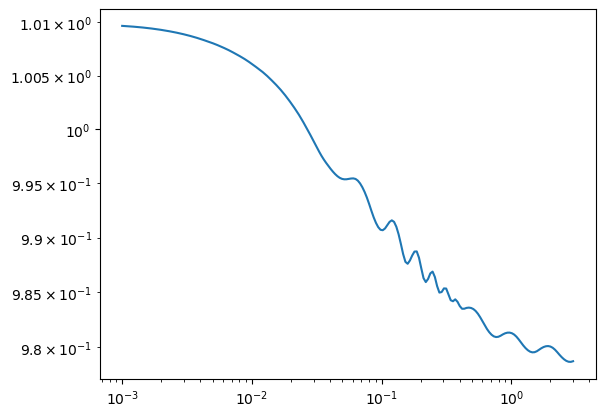

In [18]:
plt.loglog(k, [griddata(samples, tk[:,i], (0.31, 0.00001), method='nearest') for i in range(200)])
#plt.loglog(k, [griddata(samples, tk[:,i], (0.31, 0.06), method='nearest') for i in range(200)])
#plt.loglog(k, [griddata(samples, tk[:,i], (0.31, 0.49), method='nearest') for i in range(200)])

In [83]:
#%time [griddata(samples, tk[:,i], (0.31, 0.001), method='nearest') for i in range(200)[::1]]

In [12]:
np.exp(3.043)/1e10

2.096805313253679e-09

In [45]:
#interp = np.zeros(200)
interp = [bisplrep(samples[:,0][tk[:,0]>0], 
                   samples[:,1][tk[:,0]>0], tk[tk[:,0]>0][:,i], kx=5, ky=5) for i in range(200)]

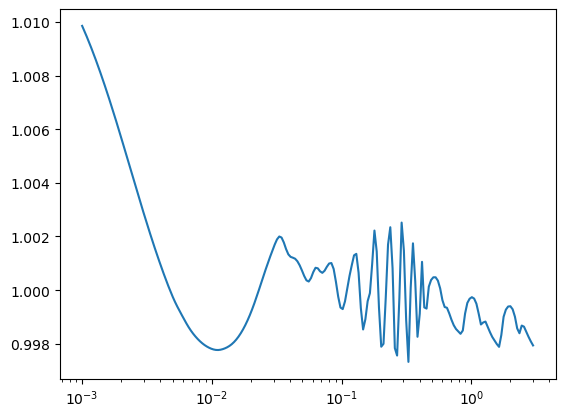

In [21]:
#plt.semilogx(k, [bisplev(0.309, 0.0001, interp[i]) for i in range(200)])
plt.semilogx(k, [bisplev(0.31, 0.0001, interp[i]) for i in range(200)])
#plt.semilogx(k, [bisplev(0.31, 0.1, interp[i]) for i in range(200)])

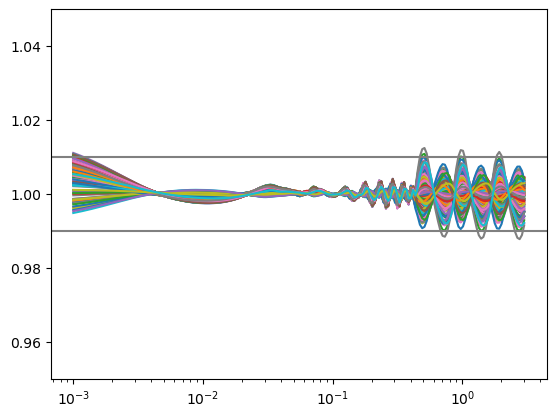

In [82]:
#n=np.random.randint(0, 2000)
for n in range(2000):
    if s_test[n][0] > 0.25 and s_test[n][0] < .35 and tk_test[n][0]>0 and s_test[n][1] < 0.15:
        #plt.semilogx(k, np.array([griddata(samples, tk[:,i], s_test[n], method='nearest') for i in range(200)])[:,0]/tk_test[n])
        plt.semilogx(k, np.array([bisplev(*s_test[n], interp[i]) for i in range(200)])/tk_test[n])
        #plt.semilogx(k, tk_test[n])
        #print(s_test[n])

plt.ylim(0.95, 1.05)
plt.axhline(y=0.99, c='grey')
plt.axhline(y=1.01, c='grey')

In [50]:
np.array([griddata(samples, tk[:,i], s_test[n], method='nearest') for i in range(200)])[:,0].shape

(200,)

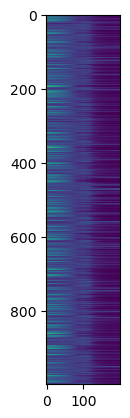

In [24]:
plt.imshow(tk)

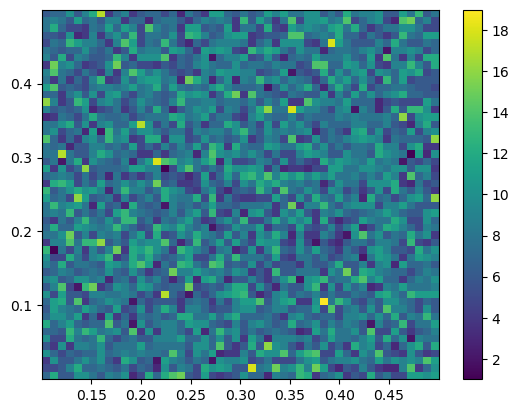

In [17]:
plt.hist2d(samples[:,0], samples[:,1], bins=50)
plt.colorbar()

In [20]:
samples[:,1]

array([-7.78278324e-01, -2.81412390e+00, -3.07444355e+00, -6.97797263e-01,
       -2.95240534e+00, -5.27769228e-01, -2.92171395e+00, -2.25693188e+00,
       -1.48751773e+00, -8.07406249e-01, -2.84700174e+00, -3.29463603e+00,
       -4.21091940e-01, -3.02568791e+00, -6.50182401e-01, -3.94779215e-01,
       -1.27120615e+00, -1.41962960e+00, -1.83461818e+00, -1.46691064e+00,
       -1.67746528e+00, -1.34998632e+00, -2.24440306e+00, -1.18822074e+00,
       -1.29977591e+00, -2.31114974e+00, -2.04933264e+00, -2.70203664e+00,
       -2.00263885e+00, -1.94490454e+00, -1.52125043e+00, -9.25109098e-01,
       -3.39068020e-01, -1.53670367e+00, -2.42144111e+00, -8.38505326e-01,
       -1.70238677e+00, -9.90639732e-01, -1.72815543e+00, -6.04299968e-01,
       -3.26769659e-01, -1.57815019e+00, -2.87535991e+00, -2.51384209e+00,
       -2.11699660e+00, -1.39691148e+00, -1.87135261e+00, -1.79696303e+00,
       -2.35546708e+00, -1.06114313e+00, -2.46609627e+00, -1.81107038e+00,
       -1.10608658e+00, -